In [13]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np

sys.path.append(str(Path().resolve().parents[0]))

from src.data_loader import load_train_data

train = load_train_data()

In [14]:
num_features = train.select_dtypes(include=['int64','float64']).columns
cat_features = train.select_dtypes(include=['object']).columns

len(num_features), len(cat_features)

(38, 43)

In [15]:
data_quality = pd.DataFrame({
    "feature": train.columns,
    "dtype": train.dtypes.values,
    "missing_values": train.isnull().sum().values,
    "missing_percent": (train.isnull().sum().values / len(train)) * 100,
    "unique_values": train.nunique().values
})

data_quality = data_quality.sort_values("missing_percent", ascending=False)

data_quality.head(20)

,feature,dtype,missing_values,missing_percent,unique_values
72,PoolQC,object,1453,99.520548,3
74,MiscFeature,object,1406,96.301370,4
6,Alley,object,1369,93.767123,2
73,Fence,object,1179,80.753425,4
25,MasVnrType,object,872,59.726027,3
57,FireplaceQu,object,690,47.260274,5
3,LotFrontage,float64,259,17.739726,110
63,GarageQual,object,81,5.547945,5
60,GarageFinish,object,81,5.547945,3
58,GarageType,object,81,5.547945,6


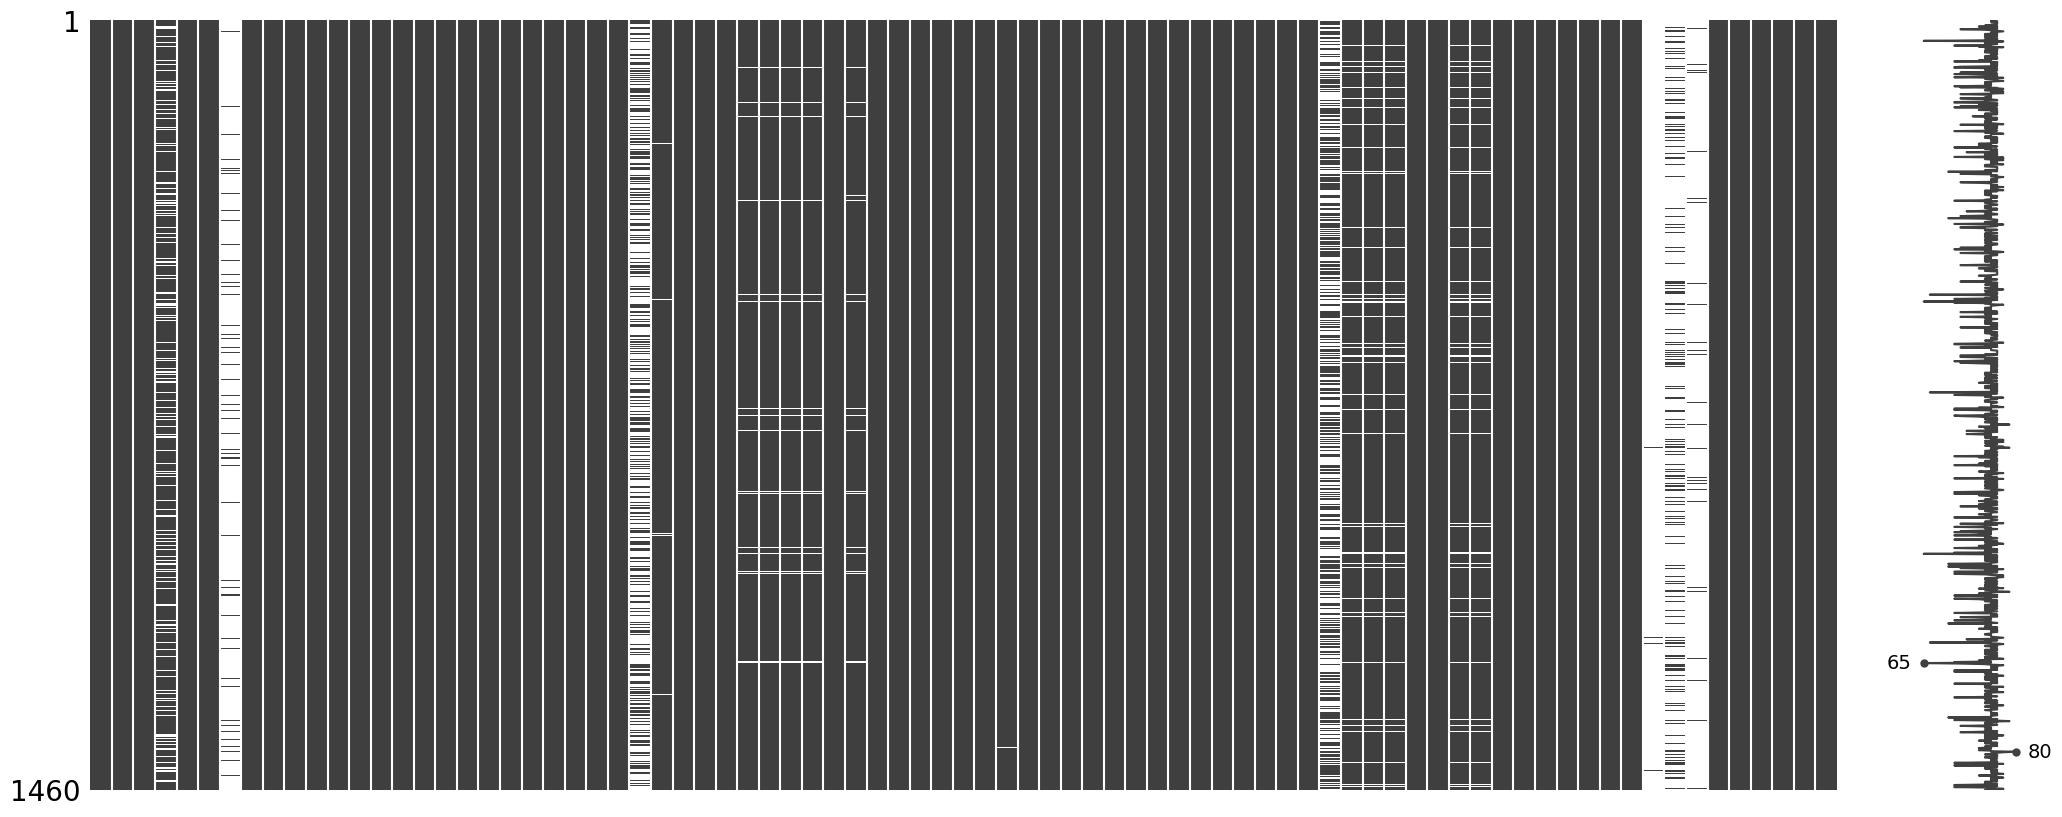

In [16]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(train)
plt.show()

<Axes: >

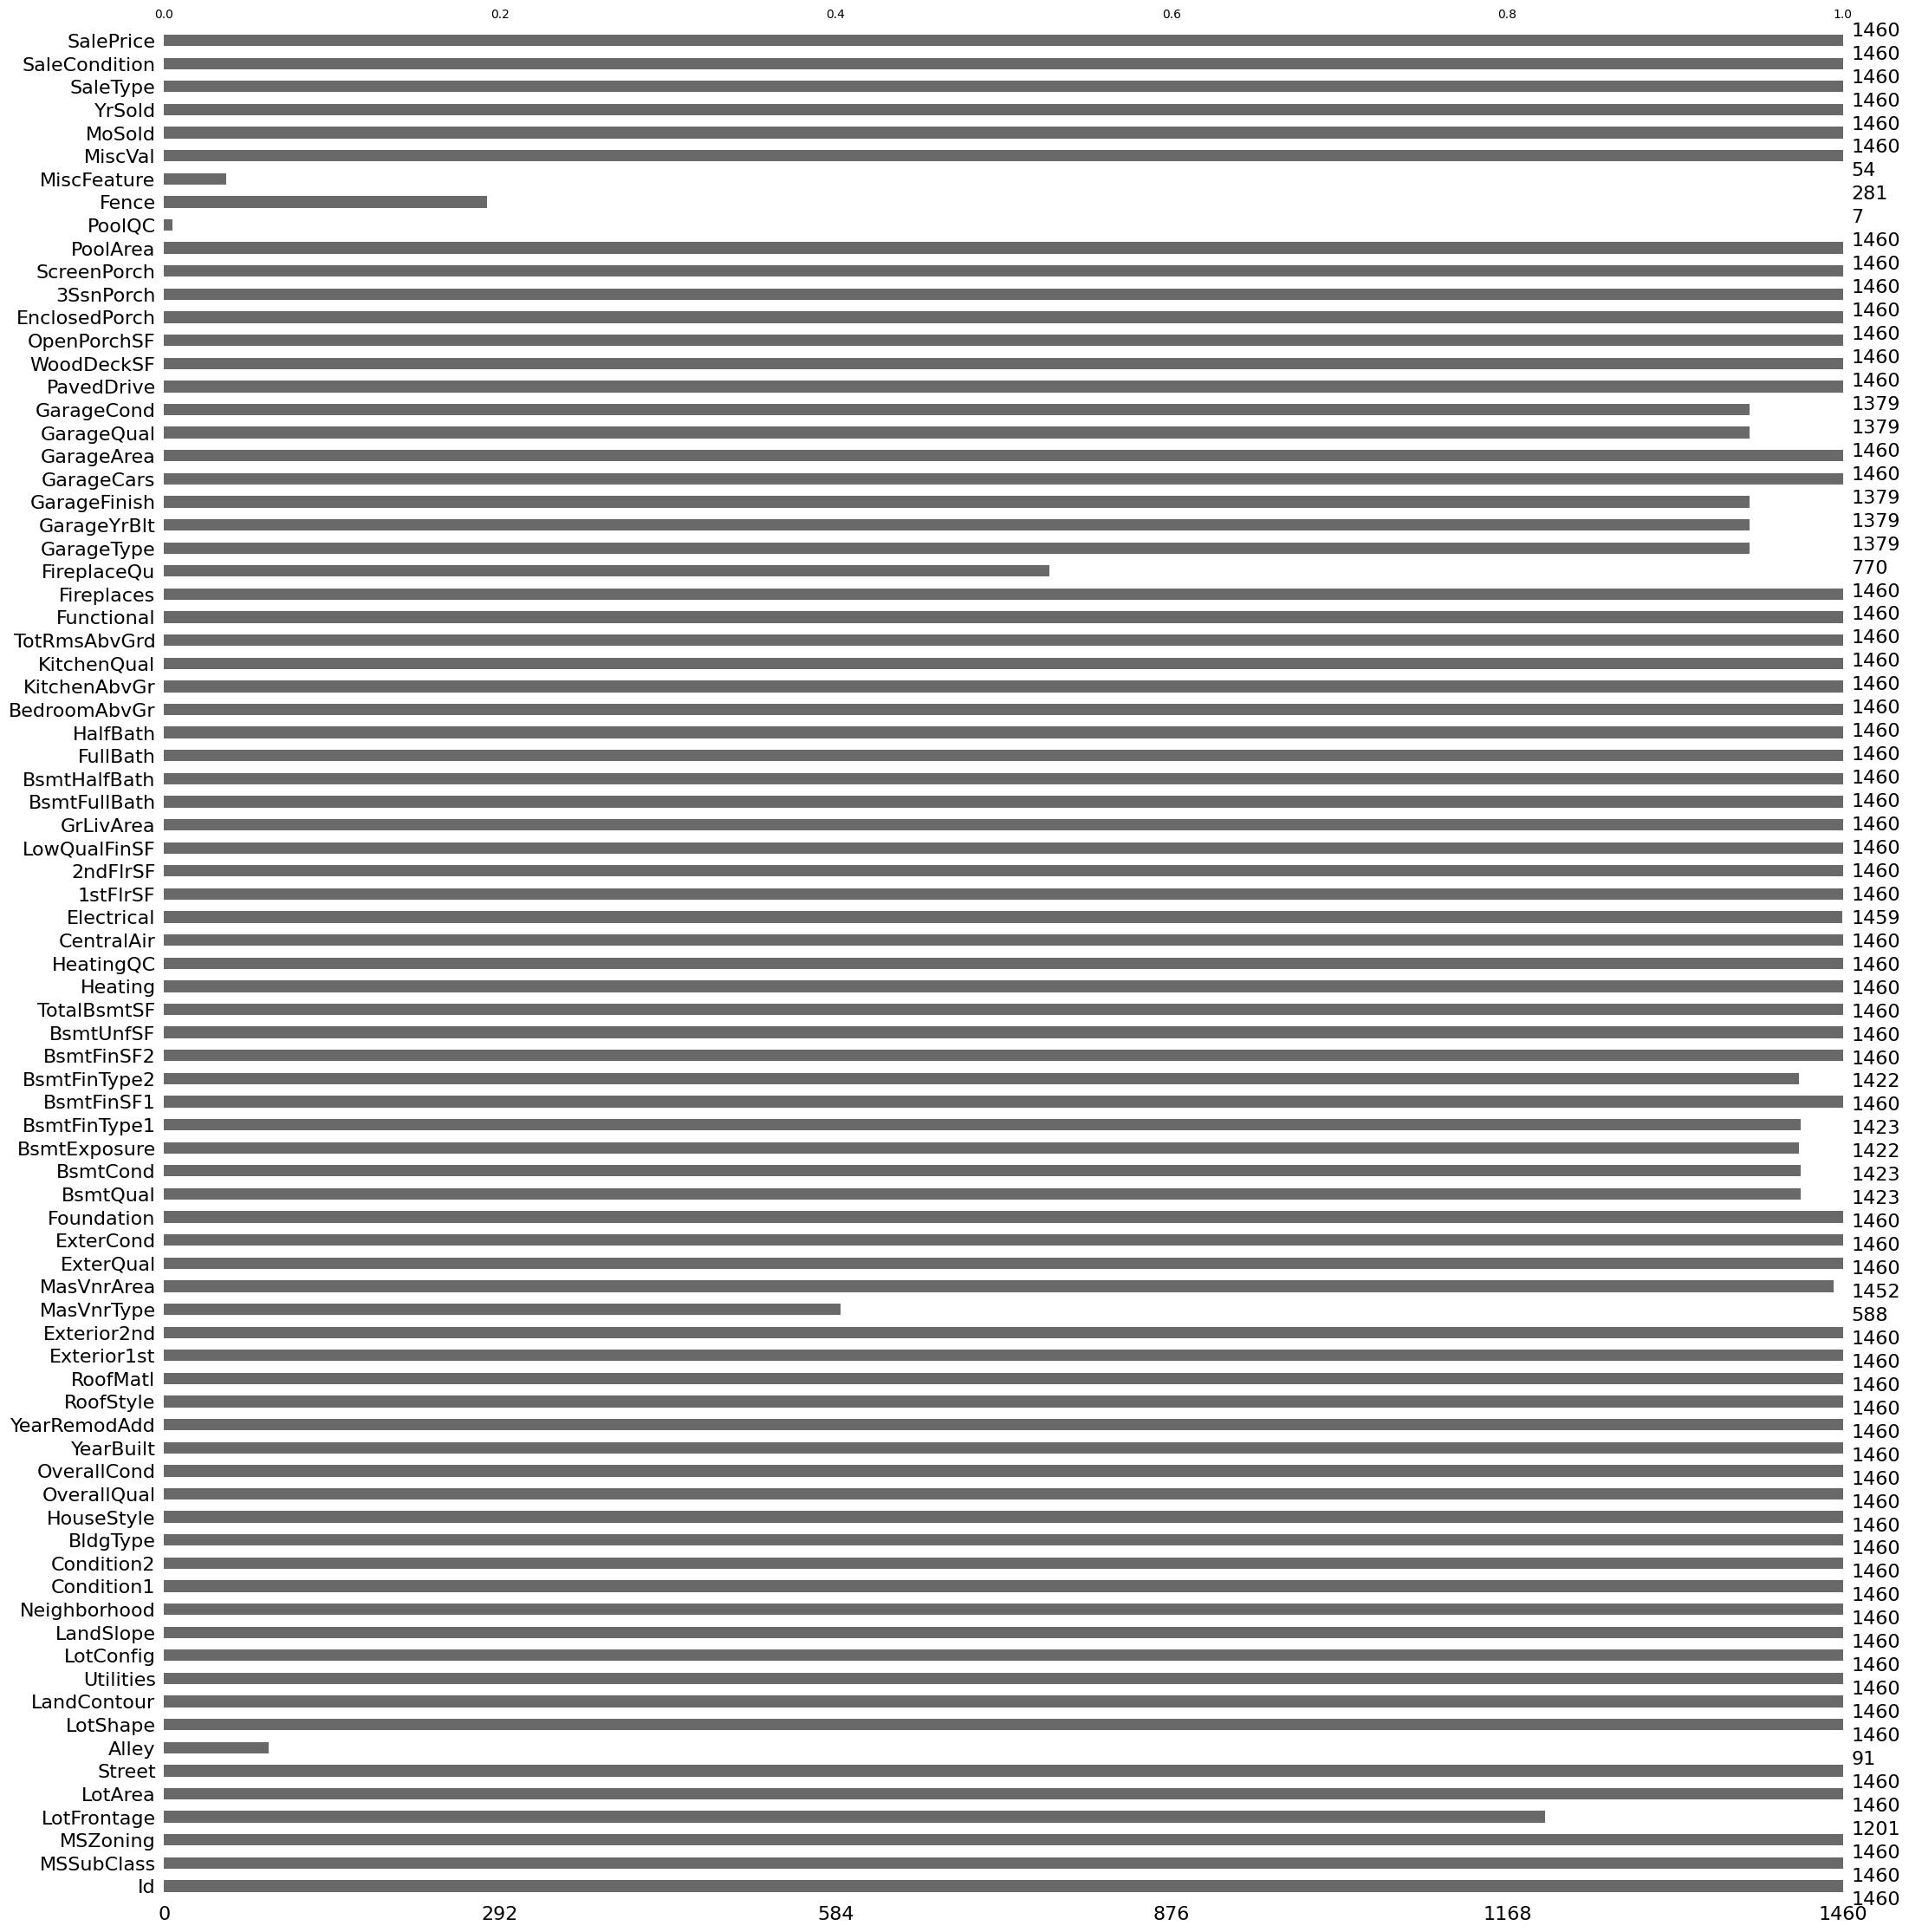

In [17]:
msno.bar(train)

In [18]:
low_variance = train.nunique().sort_values()

low_variance.head(10)

Alley           2
Street          2
Utilities       2
CentralAir      2
MasVnrType      3
HalfBath        3
GarageFinish    3
LandSlope       3
BsmtHalfBath    3
PavedDrive      3
dtype: int64

In [19]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Key observations

- Many features contain missing values
- Several missing values represent absence of a feature rather than missing data
- The target variable SalePrice is right-skewed